# Categories of Transcripts

## Load Libraries

In [1]:
import pandas as pd
from scipy.stats import chi2_contingency
import seaborn as sns
import matplotlib.pyplot as plt

## Load Data

In [2]:
df = pd.read_csv('figure5_datasets/classified_categories_consensus_2024_05_23_all.csv')
df = df[df['classification'] != 'unidentified']
df = df.groupby("classification").filter(lambda x: len(x) > 100)
df

,gene,category,ensemblGeneId,classification
0,A2M-AS1,1,ENSG00000245105,lncRNA
1,A1BG,0,ENSG00000121410,protein_coding
2,A1BG-AS1,1,ENSG00000268895,lncRNA
3,A2M,0,ENSG00000175899,protein_coding
4,A2ML1-AS1,2,ENSG00000256661,lncRNA
...,...,...,...,...
59281,ZYXP1,3,ENSG00000274572,unprocessed_pseudogene
59282,hsa-mir-1253,3,ENSG00000272920,lncRNA
59283,hsa-mir-423,3,ENSG00000266919,lncRNA
59284,ZZEF1,0,ENSG00000074755,protein_coding


## Create Contingency Table (Supplementary Table 1)

In [3]:
# create a contingency table
contingency_table = pd.crosstab(df['category'], df['classification'])
contingency_table

classification,IG_V_gene,IG_V_pseudogene,TEC,TR_V_gene,lncRNA,miRNA,misc_RNA,processed_pseudogene,protein_coding,rRNA_pseudogene,snRNA,snoRNA,transcribed_processed_pseudogene,transcribed_unitary_pseudogene,transcribed_unprocessed_pseudogene,unprocessed_pseudogene
category,,,,,,,,,,,,,,,,
0,69,0,0,0,0,0,0,0,7743,0,0,0,0,0,0,0
1,62,26,739,83,10851,8,386,4275,10700,6,68,164,352,114,654,649
2,14,149,271,23,5539,497,641,5760,1438,370,1186,110,145,41,254,1820
3,0,8,6,0,112,668,11,144,18,113,409,54,4,0,7,78


## Perform Chi Square Analysis

In [4]:
chi2, p, dof, expected = chi2_contingency(contingency_table)

print("Chi-squared statistic:", chi2)
print("p-value:", p)

if p < 0.05:
    print("There is a significant difference in the proportion of classifications between categories.")
else:
    print("There is no significant difference in the proportion of classifications between categories.")

Chi-squared statistic: 42520.48388812535
p-value: 0.0
There is a significant difference in the proportion of classifications between categories.


## Create Proportion of Transcripts by Type Heatmap

In [5]:
category_proportions = contingency_table.div(contingency_table.sum(axis=0), axis=1)
column_map = {'IG_V_gene':1, 'IG_V_pseudogene':2, 'TEC':3, 'TR_V_gene':4, 'lncRNA':5, 'miRNA':6,
       'misc_RNA':7, 'processed_pseudogene':8, 'protein_coding':9, 'rRNA_pseudogene':10,
       'snRNA':11, 'snoRNA':12, 'transcribed_processed_pseudogene':13,
       'transcribed_unitary_pseudogene':14, 'transcribed_unprocessed_pseudogene':15,
       'unprocessed_pseudogene':16}
category_proportions.columns = category_proportions.columns.map(column_map)
category_proportions.columns.name = 'Transcript Functional Categories'

category_proportions.index = list(range(1, 5))
category_proportions.index.name = 'Transcript Experimental Categories'
category_proportions

Transcript Functional Categories,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16
Transcript Experimental Categories,,,,,,,,,,,,,,,,
1,0.475862,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.389115,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,0.427586,0.142077,0.727362,0.783019,0.657557,0.00682,0.371869,0.419982,0.537715,0.012270,0.040890,0.500000,0.702595,0.735484,0.714754,0.254810
3,0.096552,0.814208,0.266732,0.216981,0.335656,0.42370,0.617534,0.565871,0.072265,0.756646,0.713169,0.335366,0.289421,0.264516,0.277596,0.714566
4,0.000000,0.043716,0.005906,0.000000,0.006787,0.56948,0.010597,0.014147,0.000905,0.231084,0.245941,0.164634,0.007984,0.000000,0.007650,0.030624


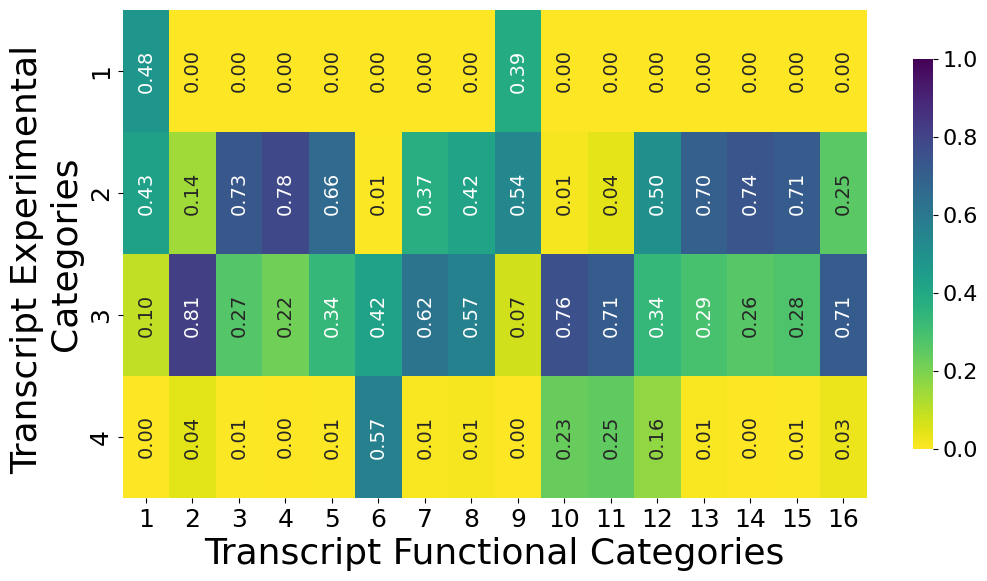

In [6]:
plt.figure(figsize=(12, 8))
sns.heatmap(category_proportions, annot=True, cmap='viridis_r', fmt='.2f', annot_kws={"rotation": 90, "fontsize": 14}, vmax=1.0, cbar_kws={'shrink': 0.8})
plt.title('')
plt.gcf().axes[-1].tick_params(axis='y', labelsize=16)
plt.xlabel('Transcript Functional Categories', fontsize=26)
plt.ylabel('Transcript Experimental \nCategories', fontsize=26)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.subplots_adjust(bottom=0.27)
plt.savefig('figure5_figures/proportions_of_transcripts_by_function_category.png', bbox_inches='tight')
plt.savefig('figure5_figures/proportions_of_transcripts_by_function_category.svg', bbox_inches='tight')

## Create Proportions of Transcripts by Category Heatmap

In [7]:
category_proportions = contingency_table.div(contingency_table.sum(axis=1), axis=0)

column_map = {'IG_V_gene':1, 'IG_V_pseudogene':2, 'TEC':3, 'TR_V_gene':4, 'lncRNA':5, 'miRNA':6,
       'misc_RNA':7, 'processed_pseudogene':8, 'protein_coding':9, 'rRNA_pseudogene':10,
       'snRNA':11, 'snoRNA':12, 'transcribed_processed_pseudogene':13,
       'transcribed_unitary_pseudogene':14, 'transcribed_unprocessed_pseudogene':15,
       'unprocessed_pseudogene':16}
category_proportions.columns = category_proportions.columns.map(column_map)
category_proportions.columns.name = 'Transcript Functional Categories'

category_proportions.index = list(range(1, 5))
category_proportions.index.name = 'Transcript Experimental Categories'
category_proportions

Transcript Functional Categories,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16
Transcript Experimental Categories,,,,,,,,,,,,,,,,
1,0.008833,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.991167,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,0.002128,0.000892,0.025363,0.002849,0.372413,0.000275,0.013248,0.146721,0.367231,0.000206,0.002334,0.005629,0.012081,0.003913,0.022446,0.022274
3,0.000767,0.008161,0.014843,0.001260,0.303374,0.027221,0.035108,0.315478,0.078760,0.020265,0.064958,0.006025,0.007942,0.002246,0.013912,0.099682
4,0.000000,0.004902,0.003676,0.000000,0.068627,0.409314,0.006740,0.088235,0.011029,0.069240,0.250613,0.033088,0.002451,0.000000,0.004289,0.047794


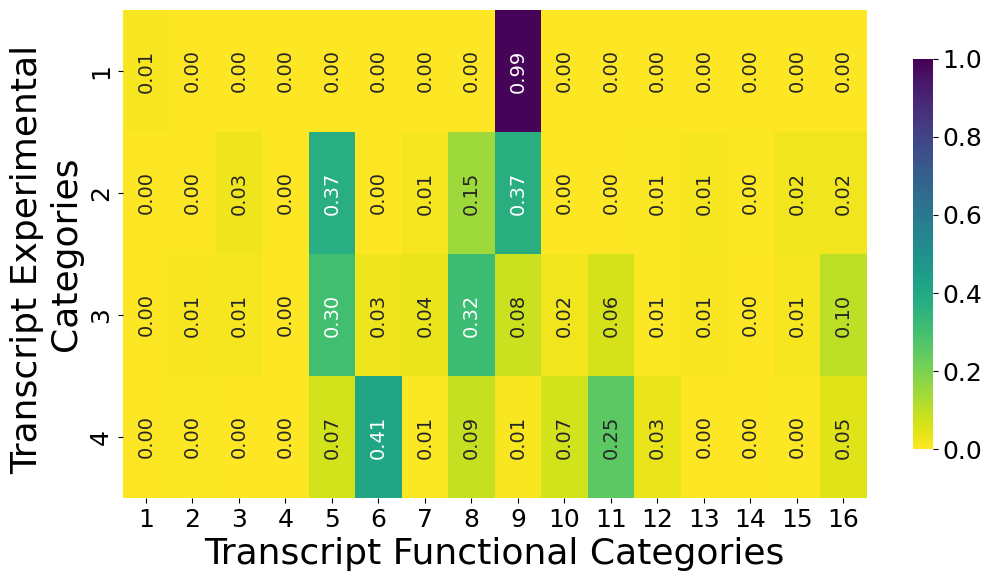

In [8]:
plt.figure(figsize=(12, 8))
sns.heatmap(category_proportions, annot=True, cmap='viridis_r', fmt='.2f', annot_kws={"rotation": 90, "fontsize": 14}, vmax=1.0, cbar_kws={'shrink': 0.8})

plt.title('')
plt.gcf().axes[-1].tick_params(axis='y', labelsize=16)
plt.xlabel('Transcript Functional Categories', fontsize=26)
plt.ylabel('Transcript Experimental \nCategories', fontsize=26)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.subplots_adjust(bottom=0.27)

# Get the color bar
cbar = plt.gcf().axes[-1]
cbar.tick_params(labelsize=18)  # Set the tick label size
cbar.set_ylabel(cbar.get_ylabel(), fontsize=18)  # Set the label size

plt.savefig('figure5_figures/proportions_of_transcripts_by_experiment_category.png', bbox_inches='tight')
plt.savefig('figure5_figures/proportions_of_transcripts_by_experiment_category.svg', bbox_inches='tight')

In [9]:
'''
# Calculate overall proportions
overall_proportions = df['classification'].value_counts(normalize=True)

# Calculate proportions for each category
#category_proportions = contingency_table.div(contingency_table.sum(axis=1), axis=0)
#category_proportions.to_csv('data/heatmap_table_by_category.csv')

category_proportions = contingency_table.div(contingency_table.sum(axis=0), axis=1)
category_proportions.to_csv('data/heatmap_table_by_type.csv')
print(category_proportions)
print(overall_proportions)
# Calculate differences between category proportions and overall proportions
proportion_diff = category_proportions.sub(overall_proportions, axis=1)
proportion_diff.to_csv('data/heatmap_table_by_category_proportional.csv')

# Adjusting the heatmap with increased bottom margin and better readability of x-axis labels
plt.figure(figsize=(12, 8))
#sns.heatmap(proportion_diff, annot=True, cmap='YlGnBu', fmt='.2f', annot_kws={"rotation": 90})
sns.heatmap(category_proportions, annot=True, cmap='YlGnBu', fmt='.2f', annot_kws={"rotation": 90})
plt.title('Heatmap of Classification Proportion Differences by Category')
plt.xticks(rotation=45, ha='right')
plt.title('')
plt.subplots_adjust(bottom=0.27)  # Increase space at the bottom
plt.show()
'''

'\n# Calculate overall proportions\noverall_proportions = df[\'classification\'].value_counts(normalize=True)\n\n# Calculate proportions for each category\n#category_proportions = contingency_table.div(contingency_table.sum(axis=1), axis=0)\n#category_proportions.to_csv(\'data/heatmap_table_by_category.csv\')\n\ncategory_proportions = contingency_table.div(contingency_table.sum(axis=0), axis=1)\ncategory_proportions.to_csv(\'data/heatmap_table_by_type.csv\')\nprint(category_proportions)\nprint(overall_proportions)\n# Calculate differences between category proportions and overall proportions\nproportion_diff = category_proportions.sub(overall_proportions, axis=1)\nproportion_diff.to_csv(\'data/heatmap_table_by_category_proportional.csv\')\n\n# Adjusting the heatmap with increased bottom margin and better readability of x-axis labels\nplt.figure(figsize=(12, 8))\n#sns.heatmap(proportion_diff, annot=True, cmap=\'YlGnBu\', fmt=\'.2f\', annot_kws={"rotation": 90})\nsns.heatmap(category_prop